# ReefScan AI — Dataset Audit

## Tujuan

Notebook ini digunakan untuk memahami dan memvalidasi dataset
CoralConditionDataset sebelum proses preprocessing dan training.

Tahapan:
1. Memeriksa struktur dataset
2. Membaca annotation
3. Memahami label asli
4. Memeriksa distribusi label
5. Memeriksa kualitas gambar
6. Menentukan data yang layak digunakan

In [77]:
from pathlib import Path
import pandas as pd
from tqdm.notebook import tqdm
import cv2
import numpy as np

# Root project
PROJECT_DIR = Path("..")

# Dataset paths
RAW_IMAGE_DIR = PROJECT_DIR / "data" / "raw" / "coral_images"
ANNOTATION_PATH = PROJECT_DIR / "data" / "raw" / "annotations.csv"
LABELSET_PATH = PROJECT_DIR / "data" / "raw" / "labelsets.csv"
SURVEY_METADATA_PATH = PROJECT_DIR / "data" / "raw" / "surveys_metadata.csv"

print("Raw image directory :", RAW_IMAGE_DIR)
print("Annotations         :", ANNOTATION_PATH)
print("Labelsets            :", LABELSET_PATH)
print("Survey metadata     :", SURVEY_METADATA_PATH)

Raw image directory : ..\data\raw\coral_images
Annotations         : ..\data\raw\annotations.csv
Labelsets            : ..\data\raw\labelsets.csv
Survey metadata     : ..\data\raw\surveys_metadata.csv


In [78]:
annotations = pd.read_csv(ANNOTATION_PATH)
labelsets = pd.read_csv(LABELSET_PATH)
surveys_metadata = pd.read_csv(SURVEY_METADATA_PATH)

print("Annotations shape      :", annotations.shape)
print("Labelsets shape        :", labelsets.shape)
print("Survey metadata shape  :", surveys_metadata.shape)

Annotations shape      : (23965, 2)
Labelsets shape        : (9, 2)
Survey metadata shape  : (9, 11)


In [79]:
print("=== ANNOTATIONS ===")
display(annotations.head())

print("\n=== LABELSETS ===")
display(labelsets)

print("\n=== SURVEYS METADATA ===")
display(surveys_metadata.head())

=== ANNOTATIONS ===


,patchid,label
0,CBK_0001_00_20230804_0001_1,0
1,CBK_0001_00_20230804_0001_2,0
2,CBK_0001_00_20230804_0001_3,0
3,CBK_0001_00_20230804_0001_4,0
4,CBK_0001_00_20230804_0001_5,0



=== LABELSETS ===


,label,label_name
0,0,Background
1,1,Healthy coral
2,2,Compromised coral
3,3,Dead coral
4,4,Rubble
5,5,Competition
6,6,Disease
7,7,Predation
8,8,Physical issues



=== SURVEYS METADATA ===


,surveyid,transectid,survey_date,site,site_fullname,folder_name,lat_start,lng_start,camera,depth,temp
0,1,0,20230804,CBK,Chalok Baan Kao Bay,20230804_CBK,"10°03'51""N","99°49'36""E",Olympus TG-6,0.3m,31.3℃
1,2,0,20230815,TTB,Tanote Bay,20230815_TTB,10°05'00''N,99°51'03''E,Olympus TG-6,15m,31.0℃
2,3,0,20230816,TCB,Taa Chaa Bay,20230816_TCB,10°03'39''N,99°49'54''E,Olympus TG-6,5m,31.6℃
3,4,0,20230817,SKI,Shark Island,20230817_SKI,10°03'46''N,99°50'44''E,Olympus TG-6,18m,28.9℃
4,25,0,20230919,SWP,Southwest Pinnacle,20230919_SWP,9°59'56''N,99°46'43''E,Olympus TG-6,23.3m,28.6℃


## 1. Struktur Label

Dataset menggunakan anotasi multi-label. Satu `patchid` dapat memiliki
lebih dari satu label. Maka setiap label akan dipertahankan sesuai annotation dari dataset.

In [80]:
label_count_per_patch = (
    annotations["label"]
    .astype(str)
    .str.split(",")
    .str.len()
)

print(label_count_per_patch.value_counts().sort_index())

label
1    9677
2    8259
3    4181
4    1499
5     322
6      26
7       1
Name: count, dtype: int64


## 1.2 Distribusi Label Asli

Pada tahap ini kita menghitung frekuensi setiap label berdasarkan
annotation asli dataset.

Satu baris annotation dapat berisi lebih dari satu label, sehingga
label akan dipisahkan terlebih dahulu sebelum dihitung.

In [81]:
from collections import Counter

label_counter = Counter()

for label_string in annotations["label"].astype(str):
    labels = label_string.split(",")

    for label in labels:
        label_counter[int(label)] += 1

label_distribution = pd.DataFrame(
    {
        "label": list(label_counter.keys()),
        "count": list(label_counter.values())
    }
).sort_values("label")

label_distribution = label_distribution.merge(
    labelsets,
    on="label",
    how="left"
)

display(label_distribution)

,label,count,label_name
0,0,1092,Background
1,1,17332,Healthy coral
2,2,6916,Compromised coral
3,3,9193,Dead coral
4,4,2517,Rubble
5,5,2949,Competition
6,6,2902,Disease
7,7,732,Predation
8,8,2874,Physical issues


In [82]:
label_distribution["proportion"] = (
    label_distribution["count"]
    / label_distribution["count"].sum()
)

display(label_distribution)

,label,count,label_name,proportion
0,0,1092,Background,0.023480
1,1,17332,Healthy coral,0.372675
2,2,6916,Compromised coral,0.148709
3,3,9193,Dead coral,0.197669
4,4,2517,Rubble,0.054121
5,5,2949,Competition,0.063410
6,6,2902,Disease,0.062399
7,7,732,Predation,0.015740
8,8,2874,Physical issues,0.061797


## 1.3 Pemeriksaan Duplicate Patch ID

Setiap patch harus memiliki hubungan yang jelas antara gambar dan
annotation. Pada tahap ini kita memeriksa apakah terdapat `patchid`
yang muncul lebih dari satu kali.

In [83]:
duplicate_patchids = annotations[
    annotations["patchid"].duplicated(keep=False)
].sort_values("patchid")

print("Jumlah baris duplicate:", len(duplicate_patchids))
print("Jumlah patchid unik yang duplicate:",
      duplicate_patchids["patchid"].nunique())

display(duplicate_patchids.head(20))

Jumlah baris duplicate: 60
Jumlah patchid unik yang duplicate: 30


,patchid,label
8804,HNM_0031_00_20230928_0058_1,0
8834,HNM_0031_00_20230928_0058_1,1
8843,HNM_0031_00_20230928_0058_10,"1,2,3"
8812,HNM_0031_00_20230928_0058_10,"1,5"
8844,HNM_0031_00_20230928_0058_11,1
8813,HNM_0031_00_20230928_0058_11,"2,6"
8845,HNM_0031_00_20230928_0058_12,1
8814,HNM_0031_00_20230928_0058_12,"1,2,6"
8815,HNM_0031_00_20230928_0058_13,"1,2,6"
8846,HNM_0031_00_20230928_0058_13,1


## 1.4 Pemeriksaan Detail Duplicate Annotation

Beberapa `patchid` muncul lebih dari satu kali pada file annotation.
Hal ini tidak langsung dianggap sebagai error karena dataset menggunakan
multi-label annotation.

Kita akan memeriksa apakah label pada duplicate `patchid` merupakan
annotation yang perlu digabungkan.

In [84]:
duplicate_summary = (
    annotations[
        annotations["patchid"].duplicated(keep=False)
    ]
    .groupby("patchid")["label"]
    .apply(list)
    .reset_index(name="labels")
)

display(duplicate_summary)

,patchid,labels
0,HNM_0031_00_20230928_0058_1,"[0, 1]"
1,HNM_0031_00_20230928_0058_10,"[1,5, 1,2,3]"
2,HNM_0031_00_20230928_0058_11,"[2,6, 1]"
3,HNM_0031_00_20230928_0058_12,"[1,2,6, 1]"
4,HNM_0031_00_20230928_0058_13,"[1,2,6, 1]"
5,HNM_0031_00_20230928_0058_14,"[1, 1]"
6,HNM_0031_00_20230928_0058_15,"[1, 1,3]"
7,HNM_0031_00_20230928_0058_16,"[2,6, 1]"
8,HNM_0031_00_20230928_0058_17,"[1,2,6, 1,3]"
9,HNM_0031_00_20230928_0058_18,"[1,2,6, 1]"


## 1.5 Menggabungkan Multi-Label Annotation

Satu `patchid` dapat memiliki beberapa baris annotation.
Seluruh label yang terkait dengan patch yang sama akan digabungkan
menjadi satu kumpulan label unik.

Proses ini tidak menghapus informasi annotation asli.

In [85]:
def merge_labels(label_series):
    merged_labels = set()

    for label_string in label_series.astype(str):
        for label in label_string.split(","):
            merged_labels.add(int(label))

    return sorted(merged_labels)


annotations_merged = (
    annotations
    .groupby("patchid")["label"]
    .apply(merge_labels)
    .reset_index()
)

annotations_merged.head(20)

,patchid,label
0,20230412_0001_1,[2]
1,20230412_0001_10,"[1, 2]"
2,20230412_0001_11,[1]
3,20230412_0001_13,[2]
4,20230412_0001_14,"[1, 2]"
5,20230412_0001_15,"[1, 2]"
6,20230412_0001_16,[1]
7,20230412_0001_17,"[1, 2]"
8,20230412_0001_19,[2]
9,20230412_0001_2,"[1, 2]"


In [86]:
print("Jumlah annotation rows :", len(annotations))
print("Jumlah unique patchid  :", annotations["patchid"].nunique())
print("Jumlah merged patches  :", len(annotations_merged))

Jumlah annotation rows : 23965
Jumlah unique patchid  : 23935
Jumlah merged patches  : 23935


In [87]:
display(
    annotations_merged[
        annotations_merged["patchid"].isin(
            duplicate_summary["patchid"]
        )
    ]
)

,patchid,label
8656,HNM_0031_00_20230928_0058_1,"[0, 1]"
8657,HNM_0031_00_20230928_0058_10,"[1, 2, 3, 5]"
8658,HNM_0031_00_20230928_0058_11,"[1, 2, 6]"
8659,HNM_0031_00_20230928_0058_12,"[1, 2, 6]"
8660,HNM_0031_00_20230928_0058_13,"[1, 2, 6]"
8661,HNM_0031_00_20230928_0058_14,[1]
8662,HNM_0031_00_20230928_0058_15,"[1, 3]"
8663,HNM_0031_00_20230928_0058_16,"[1, 2, 6]"
8664,HNM_0031_00_20230928_0058_17,"[1, 2, 3, 6]"
8665,HNM_0031_00_20230928_0058_18,"[1, 2, 6]"


## 2. Pemeriksaan Kualitas Gambar

Sebelum menghapus gambar berdasarkan kualitas, kita terlebih dahulu
mengukur karakteristik seluruh image patch.

Parameter yang diperiksa:

- Validitas file gambar
- Resolusi gambar
- Brightness
- Contrast
- Blur menggunakan Laplacian variance

Pada tahap ini tidak ada gambar yang dihapus.
Tujuannya adalah memahami distribusi kualitas dataset sebelum menentukan
threshold filtering.

In [88]:
image_paths = list(RAW_IMAGE_DIR.rglob("*.jpg"))

print("Total JPG images:", len(image_paths))
print("First 5 images:")

for path in image_paths[:5]:
    print(path)

Total JPG images: 26431
First 5 images:
..\data\raw\coral_images\20230421_preliminary_survey\20230412_0001.jpg
..\data\raw\coral_images\20230421_preliminary_survey\20230412_0002.jpg
..\data\raw\coral_images\20230421_preliminary_survey\20230412_0003.jpg
..\data\raw\coral_images\20230421_preliminary_survey\20230412_0004.jpg
..\data\raw\coral_images\20230421_preliminary_survey\20230412_0005.jpg


In [89]:
# Buat mapping nama file tanpa ekstensi -> path gambar
image_map = {
    path.stem: path
    for path in image_paths
}

# Tambahkan path gambar berdasarkan patchid
annotations_merged["image_path"] = (
    annotations_merged["patchid"]
    .map(image_map)
)

print("Total merged patches :", len(annotations_merged))
print("Images found         :", annotations_merged["image_path"].notna().sum())
print("Images missing       :", annotations_merged["image_path"].isna().sum())

Total merged patches : 23935
Images found         : 23924
Images missing       : 11


In [90]:
missing_patches = annotations_merged[
    annotations_merged["image_path"].isna()
]

print("Jumlah missing:", len(missing_patches))

display(missing_patches)

Jumlah missing: 11


,patchid,label,image_path
2294,ALK_0030_11_20230927_0019_0,"[1, 2, 3, 6]",NaN
2505,ALK_0030_11_20230927_0026_0,"[1, 2, 6, 7]",NaN
3472,ALK_0030_11_20230927_0056_0,"[1, 2, 4, 6]",NaN
4521,AOM_0032_00_20230929_0003_0,"[1, 2, 6]",NaN
9026,HNM_0031_00_20230928_0069_0,"[1, 6]",NaN
9027,HNM_0031_00_20230928_0070_0,"[1, 6]",NaN
9055,HNM_0031_00_20230928_0071_0,"[1, 6]",NaN
9884,HNM_0031_00_20230928_0095_0,"[2, 3, 6]",NaN
10300,HWB_0029_12_20230926_0009_0,"[1, 2, 6]",NaN
12220,HWB_0029_12_20230926_0066_0,[3],NaN


In [91]:
for patchid in missing_patches["patchid"]:
    print("\nPATCHID:", patchid)

    matches = [
        path for path in image_paths
        if patchid in path.stem
    ]

    for match in matches[:10]:
        print("  ", match)


PATCHID: ALK_0030_11_20230927_0019_0

PATCHID: ALK_0030_11_20230927_0026_0

PATCHID: ALK_0030_11_20230927_0056_0

PATCHID: AOM_0032_00_20230929_0003_0

PATCHID: HNM_0031_00_20230928_0069_0

PATCHID: HNM_0031_00_20230928_0070_0

PATCHID: HNM_0031_00_20230928_0071_0

PATCHID: HNM_0031_00_20230928_0095_0

PATCHID: HWB_0029_12_20230926_0009_0

PATCHID: HWB_0029_12_20230926_0066_0

PATCHID: SKI_0004_00_20230817_0082_0


In [92]:
dataset_audit = annotations_merged[
    annotations_merged["image_path"].notna()
].copy()

print("Total patches with images:", len(dataset_audit))
print("Missing patches removed from working dataset:", len(annotations_merged) - len(dataset_audit))

Total patches with images: 23924
Missing patches removed from working dataset: 11


In [93]:
def get_image_quality(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return {
            "valid": False,
            "width": None,
            "height": None,
            "brightness": None,
            "contrast": None,
            "blur_score": None
        }

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    return {
        "valid": True,
        "width": image.shape[1],
        "height": image.shape[0],
        "brightness": float(np.mean(gray)),
        "contrast": float(np.std(gray)),
        "blur_score": float(
            cv2.Laplacian(gray, cv2.CV_64F).var()
        )
    }

In [94]:
quality_results = []

for _, row in tqdm(
    dataset_audit.iterrows(),
    total=len(dataset_audit)
):
    metrics = get_image_quality(row["image_path"])

    quality_results.append(metrics)

quality_df = pd.DataFrame(quality_results)

dataset_audit = pd.concat(
    [
        dataset_audit.reset_index(drop=True),
        quality_df
    ],
    axis=1
)

display(dataset_audit.head())

  0%|          | 0/23924 [00:00<?, ?it/s]

,patchid,label,image_path,valid,width,height,brightness,contrast,blur_score
0,20230412_0001_1,[2],..\data\raw\coral_images\20230421_preliminary_...,True,512,512,91.718784,65.023522,70.801399
1,20230412_0001_10,"[1, 2]",..\data\raw\coral_images\20230421_preliminary_...,True,512,512,76.080151,38.472757,72.854960
2,20230412_0001_11,[1],..\data\raw\coral_images\20230421_preliminary_...,True,512,512,116.728912,26.899165,14.862168
3,20230412_0001_13,[2],..\data\raw\coral_images\20230421_preliminary_...,True,512,512,83.884308,30.764831,40.326007
4,20230412_0001_14,"[1, 2]",..\data\raw\coral_images\20230421_preliminary_...,True,512,512,112.300259,71.173962,78.771682


In [95]:
display(
    dataset_audit[
        [
            "width",
            "height",
            "brightness",
            "contrast",
            "blur_score"
        ]
    ].describe()
)

,width,height,brightness,contrast,blur_score
count,23924.0,23924.0,23924.000000,23924.000000,23924.000000
mean,512.0,512.0,84.102742,32.717224,158.023225
std,0.0,0.0,31.991403,12.866357,252.992343
min,512.0,512.0,1.027943,1.213257,0.719112
25%,512.0,512.0,62.698071,23.844963,62.984328
50%,512.0,512.0,81.597889,32.062906,93.445935
75%,512.0,512.0,102.842480,40.579985,161.160965
max,512.0,512.0,224.640427,95.001990,12646.155481


## 2.1 Distribusi Quality Metrics

Sebelum menentukan threshold filtering, distribusi brightness, contrast,
dan blur score divisualisasikan untuk memahami karakteristik dataset.

Threshold filtering akan ditentukan berdasarkan distribusi data dan
divalidasi secara visual sebelum gambar dihapus.

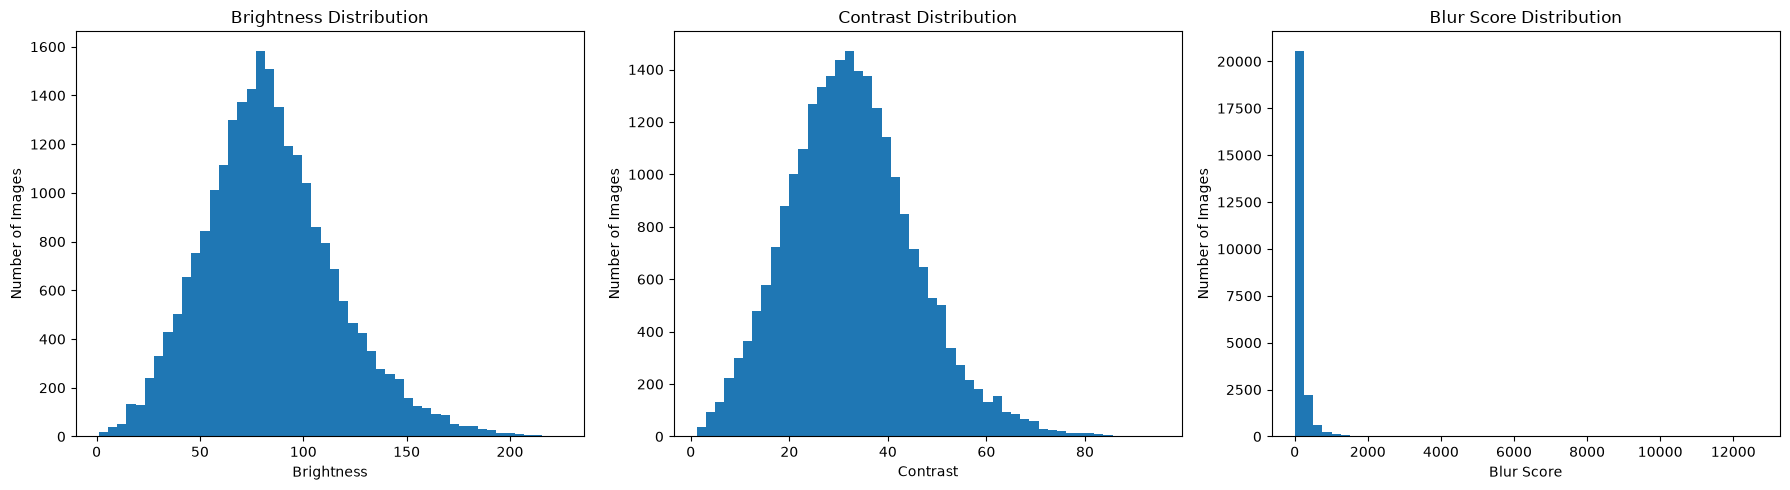

In [96]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(dataset_audit["brightness"], bins=50)
axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Brightness")
axes[0].set_ylabel("Number of Images")

axes[1].hist(dataset_audit["contrast"], bins=50)
axes[1].set_title("Contrast Distribution")
axes[1].set_xlabel("Contrast")
axes[1].set_ylabel("Number of Images")

axes[2].hist(dataset_audit["blur_score"], bins=50)
axes[2].set_title("Blur Score Distribution")
axes[2].set_xlabel("Blur Score")
axes[2].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [97]:
display(
    dataset_audit[
        ["brightness", "contrast", "blur_score"]
    ].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

,brightness,contrast,blur_score
0.01,18.880172,6.580920,4.855441
0.05,35.155087,12.688529,14.462606
0.25,62.698071,23.844963,62.984328
0.50,81.597889,32.062906,93.445935
0.75,102.842480,40.579985,161.160965
0.95,141.765060,55.011410,489.773258
0.99,172.211210,67.352489,1136.151491


## 2.2 Visual Inspection of Quality Outliers

Sebelum menentukan threshold final, kandidat gambar dengan kualitas
paling ekstrem diperiksa secara visual.

Kandidat yang diperiksa:
- sangat gelap
- sangat terang
- blur dengan skor sangat rendah

Tahap ini memastikan bahwa threshold statistik benar-benar sesuai
dengan kualitas visual gambar.

In [99]:
import matplotlib.pyplot as plt

dark_images = dataset_audit[
    dataset_audit["brightness"] < 20
].sort_values("brightness").head(12)

bright_images = dataset_audit[
    dataset_audit["brightness"] > 170
].sort_values("brightness", ascending=False).head(12)

blur_images = dataset_audit[
    dataset_audit["blur_score"] < 15
].sort_values("blur_score").head(12)

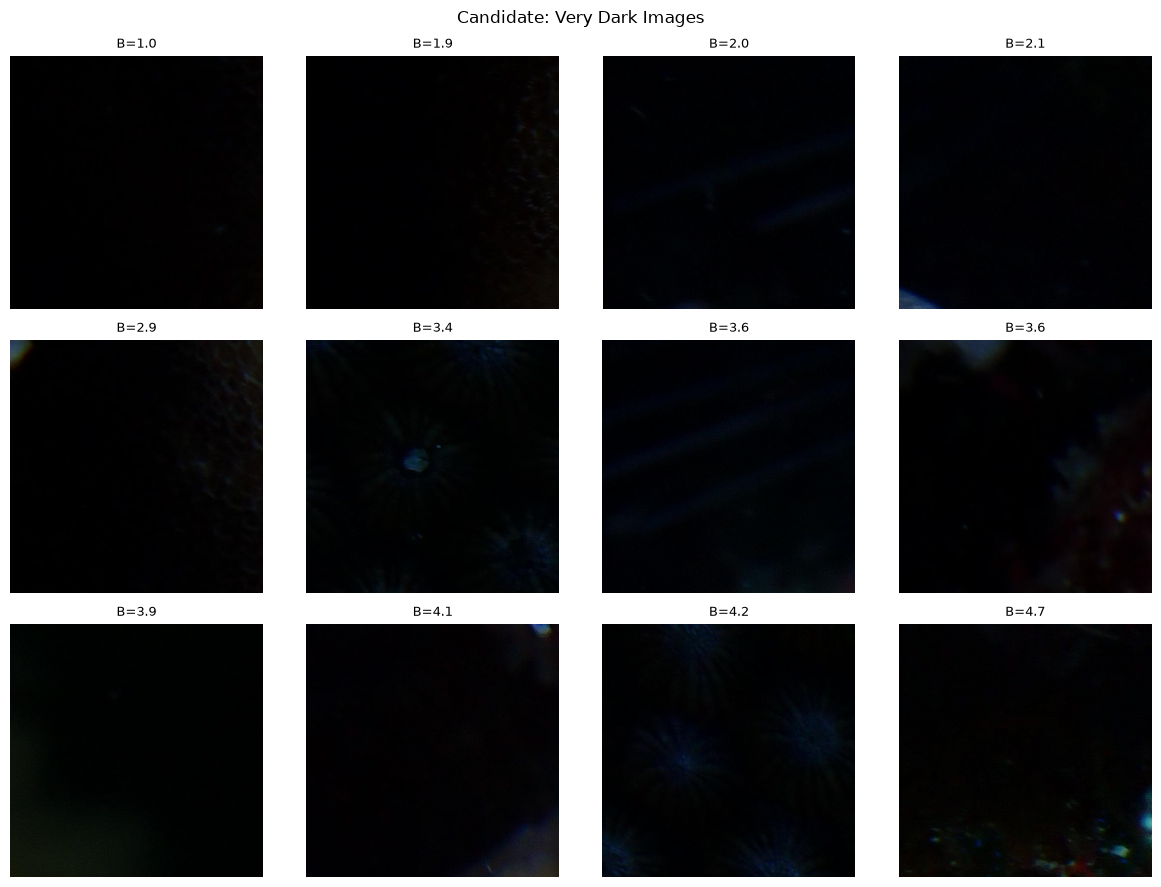

In [100]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, dark_images.iterrows()):
    image = plt.imread(row["image_path"])
    ax.imshow(image)
    ax.set_title(
        f"B={row['brightness']:.1f}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Candidate: Very Dark Images")
plt.tight_layout()
plt.show()

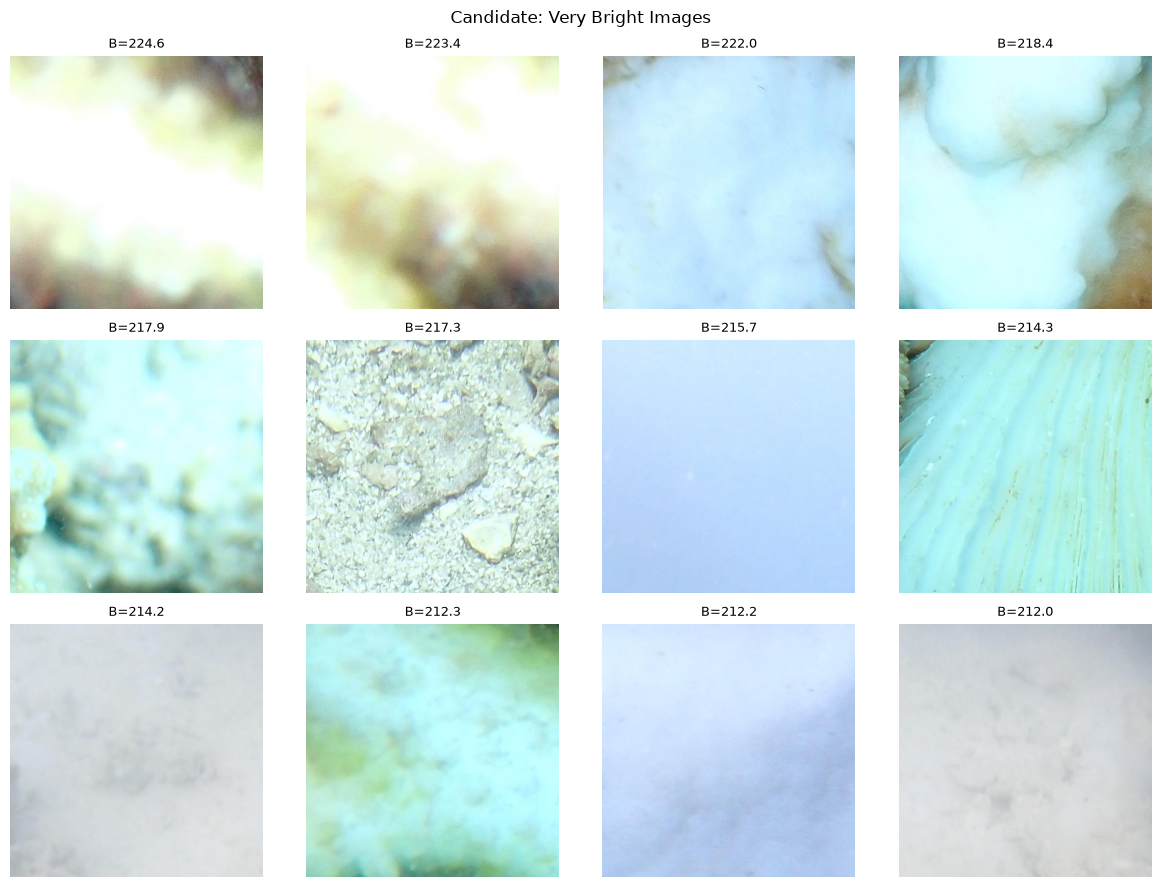

In [101]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, bright_images.iterrows()):
    image = plt.imread(row["image_path"])
    ax.imshow(image)
    ax.set_title(
        f"B={row['brightness']:.1f}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Candidate: Very Bright Images")
plt.tight_layout()
plt.show()

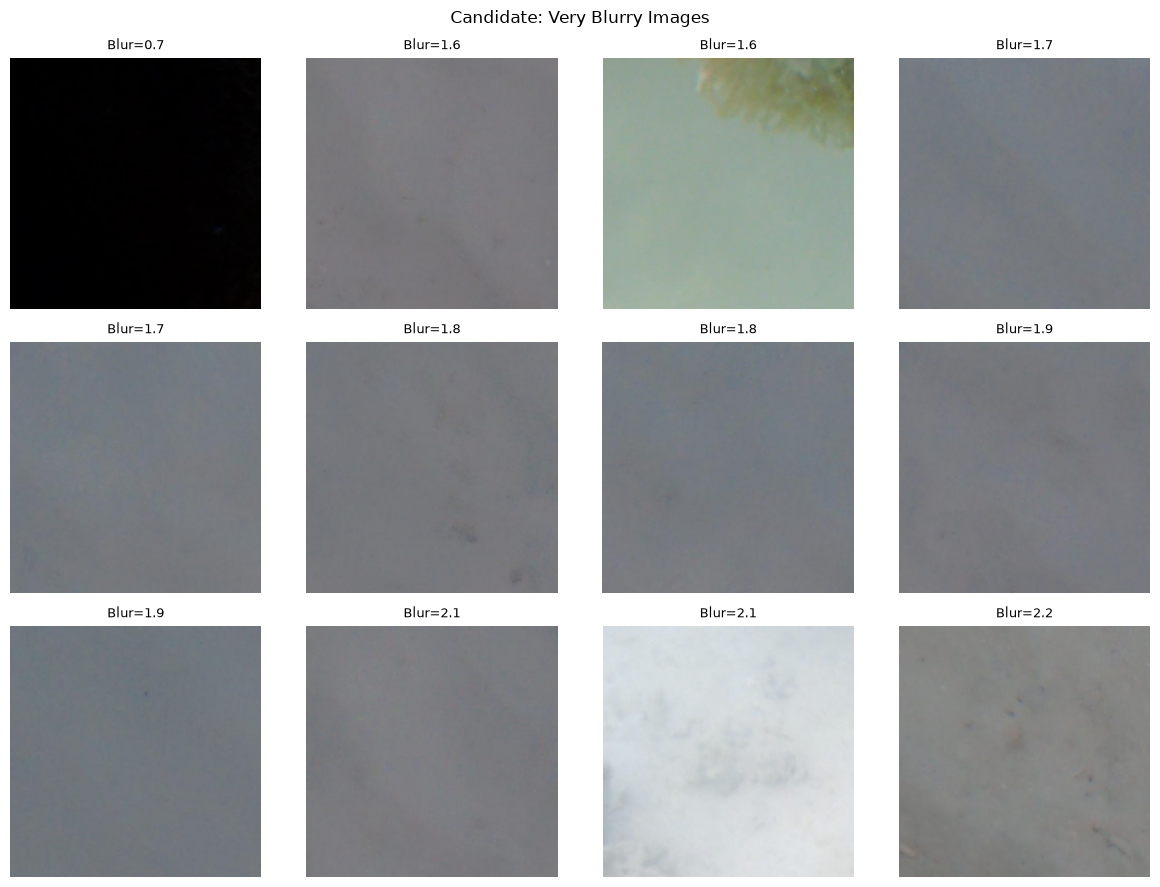

In [102]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, blur_images.iterrows()):
    image = plt.imread(row["image_path"])
    ax.imshow(image)
    ax.set_title(
        f"Blur={row['blur_score']:.1f}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle("Candidate: Very Blurry Images")
plt.tight_layout()
plt.show()

## 2.3 Quality Filtering

Berdasarkan distribusi quality metrics dan inspeksi visual, kandidat
gambar berkualitas sangat rendah ditandai berdasarkan tiga kondisi:

- Brightness < 20 → terlalu gelap
- Brightness > 170 → terlalu terang
- Blur score < 15 → terlalu blur

Gambar raw tidak dihapus. Kita hanya membuat penanda kualitas untuk
menentukan dataset yang layak digunakan pada tahap berikutnya.

In [104]:
def get_quality_issues(row):
    issues = []

    if row["brightness"] < 20:
        issues.append("too_dark")

    if row["brightness"] > 170:
        issues.append("too_bright")

    if row["blur_score"] < 15:
        issues.append("too_blurry")

    if not row["valid"]:
        issues.append("invalid")

    return issues


dataset_audit["quality_issues"] = dataset_audit.apply(
    get_quality_issues,
    axis=1
)

dataset_audit["is_quality_issue"] = (
    dataset_audit["quality_issues"].str.len() > 0
)

In [105]:
print(
    "Total patches:",
    len(dataset_audit)
)

print(
    "Quality issues:",
    dataset_audit["is_quality_issue"].sum()
)

print(
    "Good quality:",
    (~dataset_audit["is_quality_issue"]).sum()
)

Total patches: 23924
Quality issues: 1661
Good quality: 22263


In [106]:
from collections import Counter

issue_counter = Counter()

for issues in dataset_audit["quality_issues"]:
    issue_counter.update(issues)

print(issue_counter)

Counter({'too_blurry': 1247, 'too_bright': 270, 'too_dark': 262})


## 2.4 Dampak Quality Filtering terhadap Distribusi Label

Sebelum membentuk dataset bersih, distribusi label antara gambar yang
dipertahankan dan gambar yang ditandai sebagai quality issue dibandingkan.

Tujuannya memastikan proses quality filtering tidak secara tidak proporsional
menghilangkan label tertentu.

In [107]:
quality_label_data = dataset_audit[
    ["label", "is_quality_issue"]
].explode("label")

quality_label_data["label"] = (
    quality_label_data["label"].astype(int)
)

quality_label_summary = (
    quality_label_data
    .groupby(["label", "is_quality_issue"])
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            False: "kept",
            True: "quality_issue"
        }
    )
    .reset_index()
)

quality_label_summary = quality_label_summary.merge(
    labelsets,
    on="label",
    how="left"
)

quality_label_summary["issue_rate"] = (
    quality_label_summary["quality_issue"]
    /
    (
        quality_label_summary["kept"]
        + quality_label_summary["quality_issue"]
    )
)

display(quality_label_summary)

,label,kept,quality_issue,label_name,issue_rate
0,0,628,464,Background,0.424908
1,1,16648,654,Healthy coral,0.037799
2,2,6758,151,Compromised coral,0.021856
3,3,8624,565,Dead coral,0.061487
4,4,2260,256,Rubble,0.101749
5,5,2889,59,Competition,0.020014
6,6,2850,42,Disease,0.014523
7,7,721,10,Predation,0.013680
8,8,2793,81,Physical issues,0.028184


In [108]:
quality_label_summary["issue_rate_percent"] = (
    quality_label_summary["issue_rate"] * 100
).round(2)

display(
    quality_label_summary[
        [
            "label",
            "label_name",
            "kept",
            "quality_issue",
            "issue_rate_percent"
        ]
    ]
)

,label,label_name,kept,quality_issue,issue_rate_percent
0,0,Background,628,464,42.49
1,1,Healthy coral,16648,654,3.78
2,2,Compromised coral,6758,151,2.19
3,3,Dead coral,8624,565,6.15
4,4,Rubble,2260,256,10.17
5,5,Competition,2889,59,2.00
6,6,Disease,2850,42,1.45
7,7,Predation,721,10,1.37
8,8,Physical issues,2793,81,2.82


## 2.5 Membentuk Dataset Bersih

Patch dengan masalah kualitas akan dikeluarkan dari dataset kerja.

Label `Background (0)` tidak digunakan sebagai target model.
Label kondisi dan stressor (1–8) tetap dipertahankan sesuai annotation asli.

Raw images tidak diubah atau dihapus.

In [109]:
quality_clean = dataset_audit[
    ~dataset_audit["is_quality_issue"]
].copy()

print("Before quality filtering :", len(dataset_audit))
print("After quality filtering  :", len(quality_clean))

Before quality filtering : 23924
After quality filtering  : 22263


In [110]:
quality_clean["labels"] = quality_clean["label"].apply(
    lambda labels: [label for label in labels if label != 0]
)

In [111]:
background_only = quality_clean[
    quality_clean["labels"].apply(len) == 0
]

print("Background-only patches:", len(background_only))

Background-only patches: 628


## 2.6 Finalisasi Dataset Bersih

Patch yang hanya memiliki label `Background (0)` tidak memiliki target
kondisi atau stressor dari label 1–8.

Patch tersebut tidak digunakan dalam dataset training, tetapi tetap
dipertahankan dalam catatan audit. Raw images tidak dihapus.

In [112]:
background_only = quality_clean[
    quality_clean["labels"].apply(len) == 0
].copy()

dataset_clean = quality_clean[
    quality_clean["labels"].apply(len) > 0
].copy()

print("Background-only patches :", len(background_only))
print("Final clean patches      :", len(dataset_clean))

Background-only patches : 628
Final clean patches      : 21635


In [113]:
print("Unique patchid :", dataset_clean["patchid"].nunique())
print("Missing images :", dataset_clean["image_path"].isna().sum())
print("Empty labels   :", dataset_clean["labels"].apply(len).eq(0).sum())

Unique patchid : 21635
Missing images : 0
Empty labels   : 0


In [114]:
final_label_counter = Counter()

for labels in dataset_clean["labels"]:
    final_label_counter.update(labels)

final_label_distribution = pd.DataFrame(
    {
        "label": list(final_label_counter.keys()),
        "count": list(final_label_counter.values())
    }
).sort_values("label")

final_label_distribution = final_label_distribution.merge(
    labelsets,
    on="label",
    how="left"
)

final_label_distribution["proportion"] = (
    final_label_distribution["count"]
    / final_label_distribution["count"].sum()
)

display(final_label_distribution)

,label,count,label_name,proportion
0,1,16648,Healthy coral,0.382335
1,2,6758,Compromised coral,0.155203
2,3,8624,Dead coral,0.198057
3,4,2260,Rubble,0.051903
4,5,2889,Competition,0.066348
5,6,2850,Disease,0.065453
6,7,721,Predation,0.016558
7,8,2793,Physical issues,0.064143


## 3. Remove Predation from Model Scope

The `Predation` label is excluded from the model target because it has
substantially fewer samples than the other labels after quality filtering.

The original annotations are preserved. Only the working dataset is
restricted to the remaining seven labels.

In [115]:
# Remove patches that contain the Predation label (7)
dataset_clean = dataset_clean[
    ~dataset_clean["labels"].apply(lambda labels: 7 in labels)
].copy()

# Remove label 7 from the remaining multi-label targets
dataset_clean["labels"] = dataset_clean["labels"].apply(
    lambda labels: [label for label in labels if label != 7]
)

print("Total patches after removing Predation:", len(dataset_clean))

Total patches after removing Predation: 20914


In [116]:
final_label_counter = Counter()

for labels in dataset_clean["labels"]:
    final_label_counter.update(labels)

final_label_distribution = pd.DataFrame(
    {
        "label": list(final_label_counter.keys()),
        "count": list(final_label_counter.values())
    }
).sort_values("label")

final_label_distribution = final_label_distribution.merge(
    labelsets,
    on="label",
    how="left"
)

final_label_distribution["proportion"] = (
    final_label_distribution["count"]
    / final_label_distribution["count"].sum()
)

display(final_label_distribution)

,label,count,label_name,proportion
0,1,16232,Healthy coral,0.387315
1,2,6467,Compromised coral,0.154311
2,3,8499,Dead coral,0.202797
3,4,2238,Rubble,0.053401
4,5,2865,Competition,0.068362
5,6,2820,Disease,0.067289
6,8,2788,Physical issues,0.066525


## 3. Train / Validation / Test Split

Dataset akan dibagi menjadi tiga subset:

- Training: 70%
- Validation: 15%
- Test: 15%

Karena dataset bersifat multi-label, proses stratifikasi dilakukan
berdasarkan seluruh kombinasi label agar distribusi label tetap relatif
konsisten pada ketiga subset.

In [117]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

MODEL_LABELS = [1, 2, 3, 4, 5, 6, 8]

def create_multihot(labels):
    return [
        1 if label in labels else 0
        for label in MODEL_LABELS
    ]

label_matrix = np.array(
    dataset_clean["labels"].apply(create_multihot).tolist()
)

print("Dataset shape :", dataset_clean.shape)
print("Label matrix  :", label_matrix.shape)

Dataset shape : (20914, 13)
Label matrix  : (20914, 7)


In [118]:
msss_1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    msss_1.split(dataset_clean, label_matrix)
)

train_df = dataset_clean.iloc[train_idx].copy()
temp_df = dataset_clean.iloc[temp_idx].copy()

temp_labels = label_matrix[temp_idx]

msss_2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    msss_2.split(temp_df, temp_labels)
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))

Train : 14651
Val   : 3101
Test  : 3162


## 3.1 Validasi Distribusi Label per Split

Distribusi setiap label dibandingkan pada training, validation, dan test set
untuk memastikan proses multi-label stratification bekerja dengan baik.

In [119]:
def get_label_distribution(df):
    counter = Counter()

    for labels in df["labels"]:
        counter.update(labels)

    return counter


train_distribution = get_label_distribution(train_df)
val_distribution = get_label_distribution(val_df)
test_distribution = get_label_distribution(test_df)

split_distribution = pd.DataFrame({
    "label": MODEL_LABELS,
    "train": [train_distribution.get(label, 0) for label in MODEL_LABELS],
    "val": [val_distribution.get(label, 0) for label in MODEL_LABELS],
    "test": [test_distribution.get(label, 0) for label in MODEL_LABELS]
})

split_distribution = split_distribution.merge(
    labelsets,
    on="label",
    how="left"
)

display(split_distribution)

,label,train,val,test,label_name
0,1,11362,2435,2435,Healthy coral
1,2,4527,970,970,Compromised coral
2,3,5949,1275,1275,Dead coral
3,4,1567,335,336,Rubble
4,5,2005,430,430,Competition
5,6,1974,423,423,Disease
6,8,1951,418,419,Physical issues


In [120]:
split_proportion = split_distribution.copy()

split_proportion["train_prop"] = (
    split_proportion["train"] / len(train_df)
)

split_proportion["val_prop"] = (
    split_proportion["val"] / len(val_df)
)

split_proportion["test_prop"] = (
    split_proportion["test"] / len(test_df)
)

display(
    split_proportion[
        [
            "label",
            "label_name",
            "train_prop",
            "val_prop",
            "test_prop"
        ]
    ]
)

,label,label_name,train_prop,val_prop,test_prop
0,1,Healthy coral,0.775510,0.785231,0.770082
1,2,Compromised coral,0.308989,0.312802,0.306768
2,3,Dead coral,0.406047,0.411158,0.403226
3,4,Rubble,0.106955,0.108030,0.106262
4,5,Competition,0.136851,0.138665,0.135990
5,6,Disease,0.134735,0.136408,0.133776
6,8,Physical issues,0.133165,0.134795,0.132511


In [121]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

dataset_clean.to_csv(
    PROCESSED_DIR / "cleaned_dataset.csv",
    index=False
)

train_df.to_csv(
    PROCESSED_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    PROCESSED_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DIR / "test.csv",
    index=False
)

print("Dataset audit results saved successfully.")

Dataset audit results saved successfully.
